# The stroboscopic phase grating as a phase-space probe — tutorial

A self-consistent walk-through of the transfer function in
[`docs/notes/strobo_grating_transfer_function.md`](../notes/strobo_grating_transfer_function.md),
tying together the analytic kernels in
[`spike/engines/grating_tomography.py`](../../spike/engines/grating_tomography.py) and the
full Floquet propagator [`spike/engines/strobo_sim.py`](../../spike/engines/strobo_sim.py).

**What the grating is.** $N$ weak OC pulses, one per strobe period $\Delta_t$, each a
spin-flip with a Lamb–Dicke kick $D(i\eta)$. It produces a flip *amplitude operator*
$A=-i\frac{\theta}{2}\sum_k e^{-i2\pi k\delta\Delta_t}D(\beta_k)$, $\beta_k=i\eta
e^{i(\phi_g-k\Phi)}$, $\Phi=2\pi f_{\rm lf}\Delta_t$. The qubit *observable* selects the
functional of the **characteristic function** $\chi(\beta)=\mathrm{Tr}[\rho D(\beta)]$:

| observable | signal | reconstructs |
|---|---|---|
| population $\langle A^\dagger A\rangle$ | double sum over $\chi(\beta_{k'}-\beta_k)$ | diagnostic; motion-blind on the exact strobe |
| coherence $\propto\mathrm{Tr}[\rho A]$ | single-sum DFT of $\chi$ | $\chi\to W$ (ring-limited for the bare grating) |
| spin-dependent force | $\chi(\beta)$ directly | **direct** Wigner tomography |

and $W(\alpha)=\frac{1}{\pi^2}\int d^2\beta\,\chi(\beta)e^{\alpha\beta^*-\alpha^*\beta}$.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

# make the repo importable when executed from anywhere
_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(_root, "spike")):
    _root = os.path.abspath(os.getcwd())
sys.path.insert(0, _root)

from spike.engines import grating_tomography as gt          # noqa: E402
from spike.engines.strobo_sim import (                      # noqa: E402
    strobo_detuning_scan, strobo_population_vs_cycles)

# --- PAULA OC-axial regime (Strobo2.0) -----------------------------------------
ETA = 0.389              # Lamb-Dicke parameter, OC on the lf axial mode
OMEGA = 4.99e5           # per-cycle Rabi Omega_strobo/2pi [Hz]  (fitted, displ=0 baseline)
DT = 0.769172            # strobe period DELTA_t [us] = 1/f_lf  (the motional period)
N = 50                   # number of stroboscopic cycles
F_LF = 1.0 / (DT * 1e-6)               # exact-strobe motional frequency [Hz]
THETA_PI = gt.theta_of(OMEGA, 0.02)    # per-cycle area at the pi pulse (delta_t = 0.02 us)
print(f"eta={ETA}, Omega_strobo/2pi={OMEGA/1e3:.0f} kHz, DELTA_t={DT} us, "
      f"f_lf={F_LF/1e6:.4f} MHz, N={N}")
print(f"pi-pulse per-cycle area theta = {THETA_PI:.4f} rad  (N*theta = {N*THETA_PI:.3f} ~ pi)")

eta=0.389, Omega_strobo/2pi=499 kHz, DELTA_t=0.769172 us, f_lf=1.3001 MHz, N=50
pi-pulse per-cycle area theta = 0.0627 rad  (N*theta = 3.135 ~ pi)


## 1. The comb and the exact $\eta=0$ transfer function

On the **exact strobe** the population is a state-independent Dirichlet comb (teeth at
$\delta=m f_{\rm lf}$, width $1/(N\Delta_t)$). At the actual $N\theta\approx\pi$ operating
point the closed form is the exact kicked-two-level result
$P=\frac{\sin^2(\theta/2)}{\sin^2\lambda}\sin^2(N\lambda)$,
$\cos\lambda=\cos(\theta/2)\cos(\pi\delta\Delta_t)$ — and it equals the full Floquet
population for **any** $\eta$ (the motion is invisible on resonance, all orders).

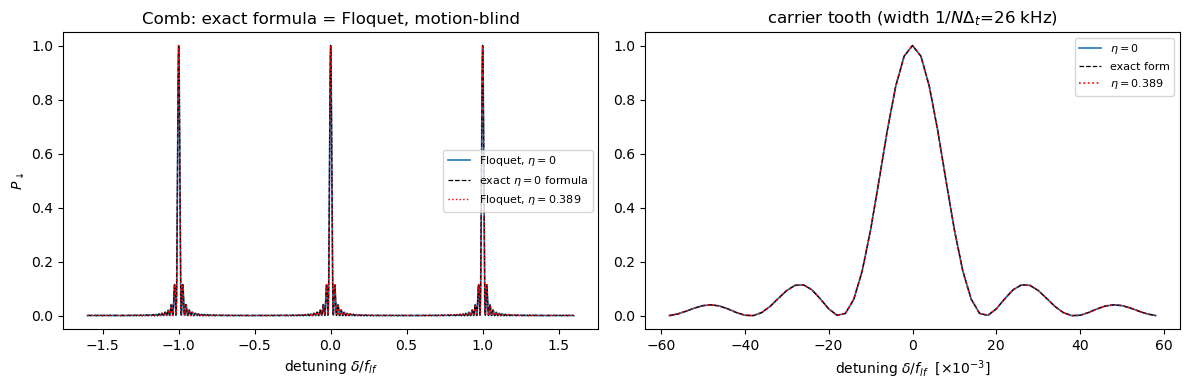

max |exact - Floquet(eta=0)| = 1.4521717162097048e-13
max |Floquet(eta=0.389) - exact| = 1.4221956945448255e-13


In [2]:
dets = np.linspace(-1.6, 1.6, 1601) * F_LF
P_eta0 = strobo_detuning_scan(0.0, OMEGA, 0.02, DT, N, F_LF, list(dets), F=4)
P_eta = strobo_detuning_scan(ETA, OMEGA, 0.02, DT, N, F_LF, list(dets), F=12)
P_exact = [gt.exact_eta0_probability(d, THETA_PI, N, DT) for d in dets]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(dets / F_LF, P_eta0, lw=1.2, label="Floquet, $\\eta=0$")
ax[0].plot(dets / F_LF, P_exact, "k--", lw=0.9, label="exact $\\eta=0$ formula")
ax[0].plot(dets / F_LF, P_eta, "r:", lw=1.0, label=f"Floquet, $\\eta={ETA}$")
ax[0].set_xlabel("detuning $\\delta / f_{lf}$"); ax[0].set_ylabel("$P_\\downarrow$")
ax[0].set_title("Comb: exact formula = Floquet, motion-blind"); ax[0].legend(fontsize=8)
# zoom the carrier tooth
m = np.abs(dets) < 0.06 * F_LF
ax[1].plot(dets[m] / F_LF * 1e3, np.array(P_eta0)[m], lw=1.2, label="$\\eta=0$")
ax[1].plot(dets[m] / F_LF * 1e3, np.array(P_exact)[m], "k--", lw=0.9, label="exact form")
ax[1].plot(dets[m] / F_LF * 1e3, np.array(P_eta)[m], "r:", lw=1.2, label=f"$\\eta={ETA}$")
ax[1].set_xlabel("detuning $\\delta / f_{lf}$  [$\\times 10^{-3}$]")
ax[1].set_title(f"carrier tooth (width $1/N\\Delta_t$={1e-3/(N*DT*1e-6):.0f} kHz)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("max |exact - Floquet(eta=0)| =", max(abs(a - b) for a, b in zip(P_exact, P_eta0)))
print("max |Floquet(eta=0.389) - exact| =", max(abs(a - b) for a, b in zip(P_eta, P_exact)))

The three curves lie on top of each other: the exact $\eta=0$ formula reproduces the
Floquet comb to machine precision, and the $\eta=0.389$ Floquet curve is identical — the
spin-flip *population* is blind to the motion on the exact strobe.

## 2. Heterodyne: the train is a sampling mixer

Detune the drive by $f_{\rm IF}$ off the carrier tooth and the **cycle-domain** population
$P_\downarrow(N)$ down-converts: on the tooth it builds the $\pi$ flop (homodyne); off it,
it nutates at $f_{\rm IF}$, first turning point $\approx 1/(2 f_{\rm IF}\Delta_t)$.

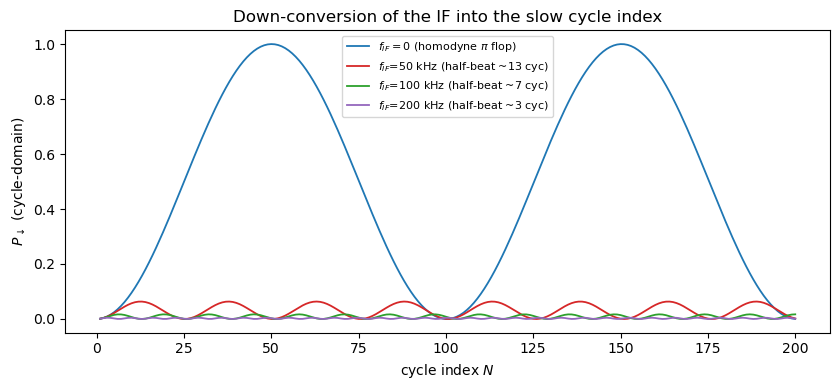

In [3]:
plt.figure(figsize=(8.5, 4))
Ncyc = np.arange(1, 201)
for fIF, col in [(0.0, "C0"), (50e3, "C3"), (100e3, "C2"), (200e3, "C4")]:
    P = strobo_population_vs_cycles(ETA, OMEGA, 0.02, DT, 200, F_LF, fIF, F=10)
    lab = "$f_{IF}=0$ (homodyne $\\pi$ flop)" if fIF == 0 else \
        f"$f_{{IF}}$={fIF/1e3:.0f} kHz (half-beat ~{1/(2*fIF*DT*1e-6):.0f} cyc)"
    plt.plot(Ncyc, P, color=col, lw=1.3, label=lab)
plt.xlabel("cycle index $N$"); plt.ylabel("$P_\\downarrow$ (cycle-domain)")
plt.title("Down-conversion of the IF into the slow cycle index")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. The two transfer-function kernels (weak pulse)

`kernel_probability` (double sum) and `kernel_coherence` (single-sum DFT of $\chi$) — both
leading-order in $\theta$. We validate the population kernel against the full Floquet
propagator for $|0\rangle$ off the strobe, and confirm the small-signal $\theta^2$ scaling.

In [4]:
f_off = 1.03 / (DT * 1e-6)                # 3% strobe mistune -> motion-sensitive
rows = []
for dt in (0.001, 0.002, 0.005, 0.010):
    th = gt.theta_of(OMEGA, dt)
    p_ana = gt.kernel_probability(gt.chi_vacuum, ETA, 0.0, 0.0, N, DT, f_off, th)
    p_num = strobo_detuning_scan(ETA, OMEGA, dt, DT, N, f_off, [0.0], F=16)[0]
    rows.append((dt, th, p_num, abs(p_ana - p_num) / p_num))
print(" delta_t/us   theta     P_down     rel.err")
for dt, th, p, e in rows:
    print(f"   {dt:.3f}    {th:.4f}   {p:.5f}    {e*100:.2f}%")
print("\n-> the §3(a) kernel is a small-signal expansion (rel.err ~ theta^2);")
print("   use the exact eta=0 form / full Floquet at the pi-pulse operating point.")

 delta_t/us   theta     P_down     rel.err
   0.001    0.0031   0.00531    0.18%
   0.002    0.0063   0.02111    0.73%
   0.005    0.0157   0.12701    4.66%
   0.010    0.0314   0.44231    20.21%

-> the §3(a) kernel is a small-signal expansion (rel.err ~ theta^2);
   use the exact eta=0 form / full Floquet at the pi-pulse operating point.


**Coherence channel.** $\mathrm{Tr}[\rho A]=-i\frac{\theta}{2}\sum_k e^{-i2\pi k\delta\Delta_t}
\chi(\beta_k)$ — a discrete Fourier transform of $\chi$ sampled on the ring $|\beta|=\eta$.
On the bare grating this only reaches $|\beta|=\eta$ (a thin ring), which is why full
tomography needs the spin-dependent-force extension (next section).

## 4. SDF characteristic-function tomography

With a spin-*dependent* displacement the coherence reads $\langle\sigma_+\rangle=\frac12
\chi(\beta)$ for a *controllable* $\beta$. Raster $\beta$ over the plane, then 2-D Fourier
transform $\chi\to W$. We do this for an **odd cat** $|\gamma\rangle-|-\gamma\rangle$ and
compare the reconstruction with the analytic Wigner (note the negative central fringe — a
genuine non-classicality witness).

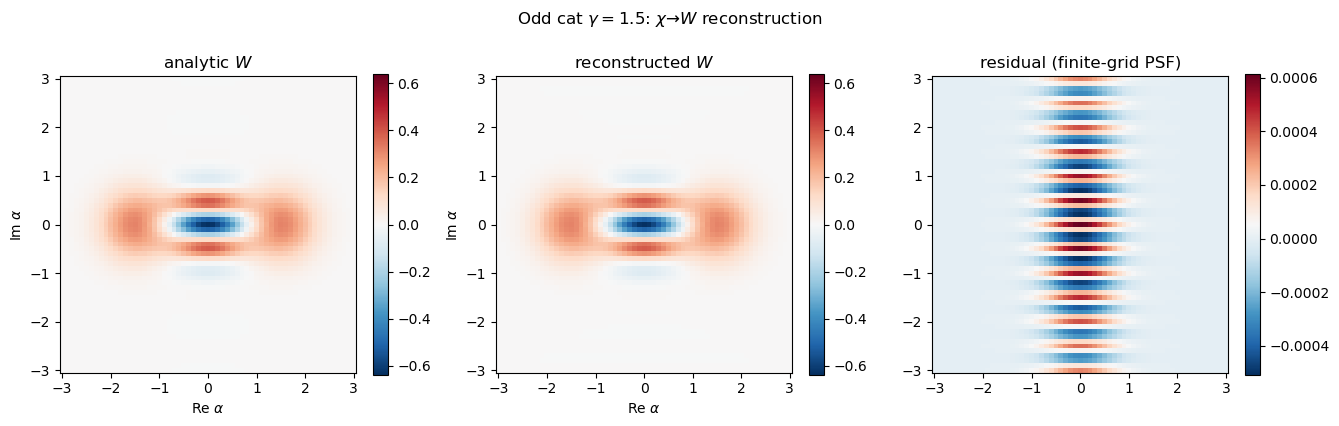

W(0): analytic=-0.6366  reconstructed=-0.6360  (= -2/pi)
max |W_rec - W_ana| = 6.12e-04


In [5]:
gamma = 1.5 + 0j
# "measure" chi on a beta-grid (ideal SDF: chi = 2<sigma_+>)
beta_pts, dbeta = gt.square_grid(6.0, 61)
chi_meas = [gt.chi_cat(b, gamma, -1) for b in beta_pts]
# reconstruct W on an alpha-grid via the engine's 2-D transform
ax_lin = np.linspace(-3, 3, 61)
AX, AY = np.meshgrid(ax_lin, ax_lin)
alpha_pts = [complex(x, y) for x, y in zip(AX.ravel(), AY.ravel())]
W_rec = np.array(gt.wigner_from_samples(beta_pts, chi_meas, alpha_pts, dbeta * dbeta)).reshape(AX.shape)
W_ana = np.array([gt.wigner_cat(a, gamma, -1) for a in alpha_pts]).reshape(AX.shape)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
vmax = np.abs(W_ana).max()
for a, dat, t in [(ax[0], W_ana, "analytic $W$"), (ax[1], W_rec, "reconstructed $W$")]:
    im = a.pcolormesh(AX, AY, dat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    a.set_title(t); a.set_xlabel("Re $\\alpha$"); a.set_ylabel("Im $\\alpha$"); a.set_aspect("equal")
    fig.colorbar(im, ax=a, fraction=0.046)
im = ax[2].pcolormesh(AX, AY, W_rec - W_ana, cmap="RdBu_r", shading="auto")
ax[2].set_title("residual (finite-grid PSF)"); ax[2].set_aspect("equal")
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.suptitle(f"Odd cat $\\gamma={gamma.real:.1f}$: $\\chi\\to W$ reconstruction", y=1.02)
plt.tight_layout(); plt.show()

print(f"W(0): analytic={gt.wigner_cat(0j, gamma, -1):+.4f}  reconstructed={W_rec[30,30]:+.4f}  (= -2/pi)")
print(f"max |W_rec - W_ana| = {np.abs(W_rec - W_ana).max():.2e}")

## 5. Sampling effects specific to the grating

**(a) The bare-grating ring.** The bare carrier grating only samples $\chi$ on $|\beta|=\eta$.
Reconstructing from that ring alone cannot recover $W$ — you get a Bessel-ring artefact,
not the state. Larger $|\beta|$ (finer phase-space detail) needs the SDF accumulation.

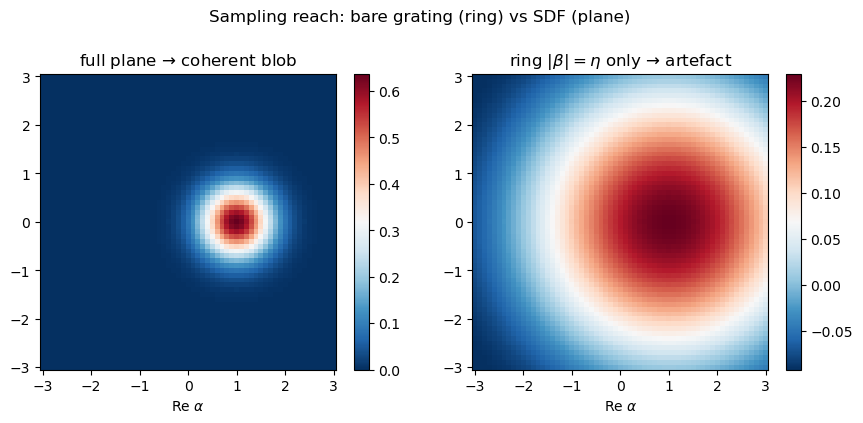

In [6]:
# reconstruct a coherent state from (i) the full plane, (ii) a thin ring |beta|=eta only
gco = 1.0 + 0.0j
ring_b = [ETA * np.exp(1j * t) * 1j for t in np.linspace(0, 2 * np.pi, 120, endpoint=False)]
ring_chi = [gt.chi_coherent(b, gco) for b in ring_b]
dphi = 2 * np.pi / 120
W_ring = np.array(gt.wigner_from_samples(ring_b, [c * ETA * dphi for c in ring_chi],
                                         alpha_pts, 1.0)).reshape(AX.shape)
W_full = np.array(gt.wigner_from_samples(beta_pts, [gt.chi_coherent(b, gco) for b in beta_pts],
                                         alpha_pts, dbeta * dbeta)).reshape(AX.shape)
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, dat, t in [(ax[0], W_full, "full plane $\\to$ coherent blob"),
                  (ax[1], W_ring, "ring $|\\beta|=\\eta$ only $\\to$ artefact")]:
    im = a.pcolormesh(AX, AY, dat, cmap="RdBu_r", shading="auto")
    a.set_title(t); a.set_aspect("equal"); a.set_xlabel("Re $\\alpha$")
    fig.colorbar(im, ax=a, fraction=0.046)
plt.suptitle("Sampling reach: bare grating (ring) vs SDF (plane)", y=1.02)
plt.tight_layout(); plt.show()

**(b) Finite $|\beta|_{\max}$ $\to$ resolution.** Truncating the $\chi$-sampling at
$|\beta|_{\max}$ convolves $W$ with a point spread of width $\sim1/|\beta|_{\max}$ — the
decoherence/finite-$N$ limit on tomographic resolution.

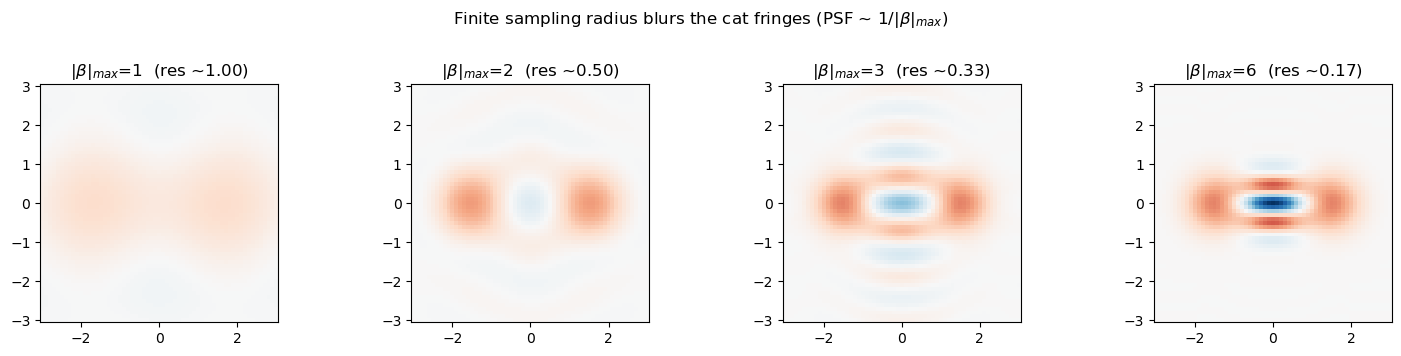

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, bmax in zip(ax, (1.0, 2.0, 3.0, 6.0)):
    bp = [b for b in beta_pts if abs(b) <= bmax]
    cv = [gt.chi_cat(b, gamma, -1) for b in bp]
    Wt = np.array(gt.wigner_from_samples(bp, cv, alpha_pts, dbeta * dbeta)).reshape(AX.shape)
    im = a.pcolormesh(AX, AY, Wt, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    a.set_title(f"$|\\beta|_{{max}}$={bmax:.0f}  (res ~{1/bmax:.2f})"); a.set_aspect("equal")
plt.suptitle("Finite sampling radius blurs the cat fringes (PSF ~ $1/|\\beta|_{max}$)", y=1.02)
plt.tight_layout(); plt.show()

**(c) Coarse $\beta$-grid $\to$ phase-space aliasing.** The $\beta$-grid spacing
$\Delta\beta$ sets a phase-space "Brillouin zone": features beyond $|\alpha|\sim\pi/\Delta\beta$
wrap (alias). Too coarse a grid folds the cat lobes back into the frame.

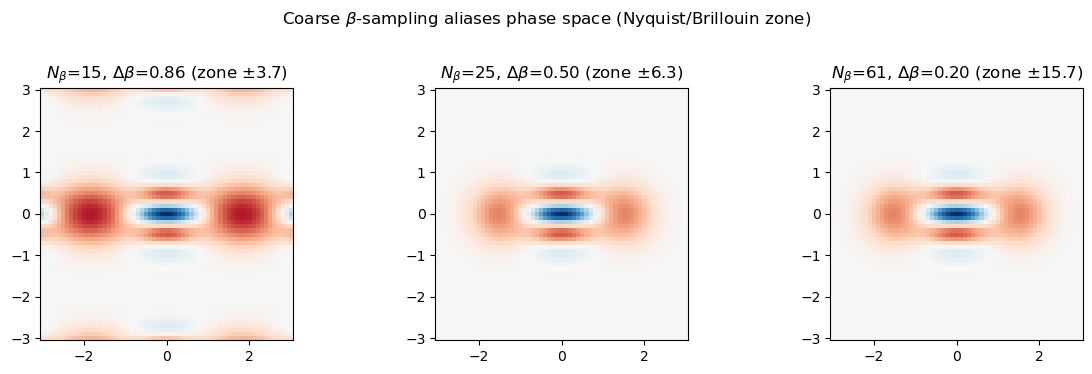

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, nb in zip(ax, (15, 25, 61)):
    bp, dbg = gt.square_grid(6.0, nb)
    cv = [gt.chi_cat(b, gamma, -1) for b in bp]
    Wa = np.array(gt.wigner_from_samples(bp, cv, alpha_pts, dbg * dbg)).reshape(AX.shape)
    im = a.pcolormesh(AX, AY, Wa, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    a.set_title(f"$N_\\beta$={nb}, $\\Delta\\beta$={2*6.0/(nb-1):.2f} "
                f"(zone $\\pm${np.pi/(2*6.0/(nb-1)):.1f})"); a.set_aspect("equal")
plt.suptitle("Coarse $\\beta$-sampling aliases phase space (Nyquist/Brillouin zone)", y=1.02)
plt.tight_layout(); plt.show()

## 6. Ramsey characteristic-function interferometer (population readout only)

The cleanest near-term experiment. Two recoil-dressed $\pi/2$ pulses — a reference
$\beta_r$ then a phase-coherent grating $\beta_g$ with relative phase $\varphi$ — make the
**population** a *linear* $\chi$ readout (no weak-amplitude measurement needed):
$$P_\downarrow(\varphi)=\tfrac12\big[1+\mathrm{Re}\big(e^{i[\varphi+\mathrm{Im}(\beta_g\beta_r^*)]}\chi(\beta_g-\beta_r)\big)\big].$$
$\varphi=0,\pi/2$ give $\mathrm{Re}\,\chi$ and $\mathrm{Im}\,\chi$ at $\Delta\beta=\beta_g-\beta_r$.
With fixed recoil $|\beta|=\eta$ and independent pulse phases,
$\Delta\beta=i\eta(e^{i\phi_g}-e^{i\phi_r})$ fills the **disk $|\Delta\beta|\le2\eta$** — a
genuine 2-D region. The identity is **exact in $\eta$** (full recoil operator $D(i\eta)$,
not a Lamb–Dicke expansion); the requirement is impulsive control $\omega_{lf}\delta t\ll1$
and a calibrated $\pi/2$ area, *not* small $\eta$.

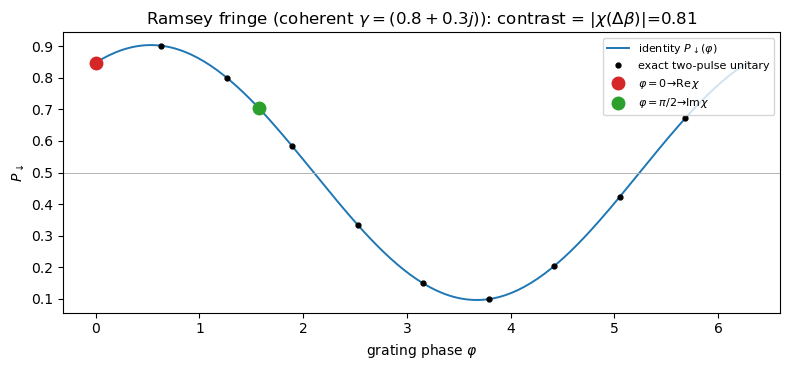

max |exact - identity| = 4.440892098500626e-16


In [9]:
# (a) the Ramsey fringe, exact two-pulse unitary vs the boxed identity
gamma = 0.8 + 0.3j
chi_g = lambda b: gt.chi_coherent(b, gamma)                       # noqa: E731
br = 1j * ETA * np.exp(1j * 0.0)
bg = 1j * ETA * np.exp(1j * 2.0)
phis = np.linspace(0, 2 * np.pi, 200)
P_ana = [gt.ramsey_population(chi_g, br, bg, ph) for ph in phis]
psi = gt.coherent_state_vec(gamma, 30)
P_exact = [gt.ramsey_population_exact(br, bg, ph, psi) for ph in phis[::20]]

plt.figure(figsize=(8, 3.8))
plt.plot(phis, P_ana, "C0", lw=1.4, label="identity $P_\\downarrow(\\varphi)$")
plt.plot(phis[::20], P_exact, "k.", ms=7, label="exact two-pulse unitary")
db = bg - br
plt.axhline(0.5, color="0.7", lw=0.7)
for ph, c, t in [(0.0, "C3", "$\\varphi=0\\to\\mathrm{Re}\\,\\chi$"),
                 (np.pi / 2, "C2", "$\\varphi=\\pi/2\\to\\mathrm{Im}\\,\\chi$")]:
    plt.plot(ph, gt.ramsey_population(chi_g, br, bg, ph), "o", color=c, ms=9, label=t)
plt.xlabel("grating phase $\\varphi$"); plt.ylabel("$P_\\downarrow$")
plt.title(f"Ramsey fringe (coherent $\\gamma={gamma}$): contrast = $|\\chi(\\Delta\\beta)|$={abs(chi_g(db)):.2f}")
plt.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()
print("max |exact - identity| =",
      max(abs(gt.ramsey_population_exact(br, bg, ph, psi) - gt.ramsey_population(chi_g, br, bg, ph))
          for ph in phis[::20]))

/Users/uwarring/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


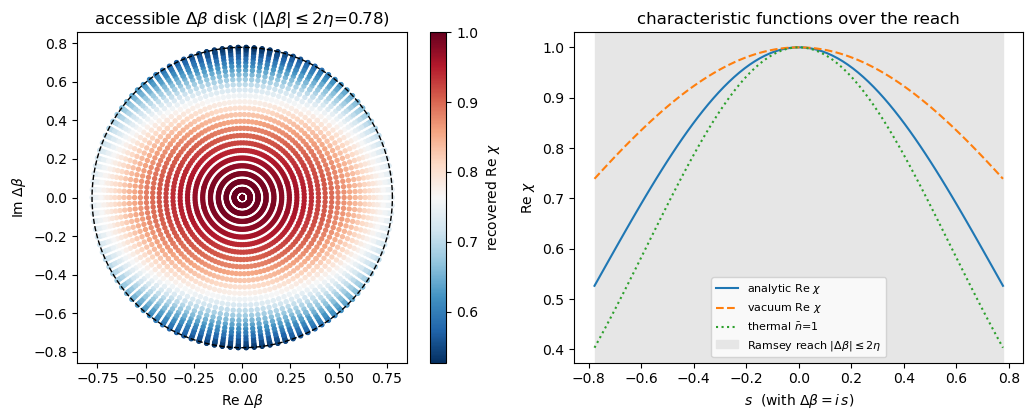

max |recovered chi - analytic| over the disk = 3.72e-16  (the identity is exact)
our regime: eta=0.389 -> Ramsey reach 2*eta=0.78; full W of larger states needs
concatenated Ramsey blocks or an SDF sequence to extend |Delta beta|.


In [10]:
# (b) the accessible disk |Delta beta| <= 2 eta, recovered chi from P(0),P(pi/2)
PR, PG = np.meshgrid(np.linspace(0, 2 * np.pi, 60), np.linspace(0, 2 * np.pi, 60))
DB = 1j * ETA * (np.exp(1j * PG) - np.exp(1j * PR))             # Delta beta over the phase grid
gamma2 = 0.5 + 0.0j
chi2 = lambda b: gt.chi_coherent(b, gamma2)                      # noqa: E731
rec_err = 0.0
ReChi = np.zeros_like(PR)
for i in range(PR.shape[0]):
    for j in range(PR.shape[1]):
        b_r = 1j * ETA * np.exp(1j * PR[i, j]); b_g = 1j * ETA * np.exp(1j * PG[i, j])
        p0 = gt.ramsey_population(chi2, b_r, b_g, 0.0)
        p90 = gt.ramsey_population(chi2, b_r, b_g, np.pi / 2)
        chi_rec = gt.ramsey_chi_from_populations(p0, p90, b_r, b_g)
        ReChi[i, j] = chi_rec.real
        rec_err = max(rec_err, abs(chi_rec - chi2(b_g - b_r)))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
sc = ax[0].scatter(DB.real.ravel(), DB.imag.ravel(), c=ReChi.ravel(), cmap="RdBu_r", s=8)
th = np.linspace(0, 2 * np.pi, 200)
ax[0].plot(2 * ETA * np.cos(th), 2 * ETA * np.sin(th), "k--", lw=1)
ax[0].set_title(f"accessible $\\Delta\\beta$ disk ($|\\Delta\\beta|\\leq2\\eta$={2*ETA:.2f})")
ax[0].set_xlabel("Re $\\Delta\\beta$"); ax[0].set_ylabel("Im $\\Delta\\beta$"); ax[0].set_aspect("equal")
fig.colorbar(sc, ax=ax[0], fraction=0.046, label="recovered Re $\\chi$")
# compare recovered vs analytic chi along a radial cut Delta beta in i*[-2eta, 2eta]
ss = np.linspace(-2 * ETA, 2 * ETA, 80)
chi_line = [chi2(1j * s) for s in ss]
ax[1].plot(ss, [c.real for c in chi_line], "C0", label="analytic Re $\\chi$")
ax[1].plot(ss, [gt.chi_vacuum(1j * s).real for s in ss], "C1--", label="vacuum Re $\\chi$")
ax[1].plot(ss, [gt.chi_thermal(1j * s, 1.0) for s in ss], "C2:", label="thermal $\\bar n$=1")
ax[1].axvspan(-2 * ETA, 2 * ETA, color="0.9", label="Ramsey reach $|\\Delta\\beta|\\leq2\\eta$")
ax[1].set_xlabel("$s$  (with $\\Delta\\beta = i\\,s$)"); ax[1].set_ylabel("Re $\\chi$")
ax[1].set_title("characteristic functions over the reach"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"max |recovered chi - analytic| over the disk = {rec_err:.2e}  (the identity is exact)")
print(f"our regime: eta={ETA} -> Ramsey reach 2*eta={2*ETA:.2f}; full W of larger states needs")
print("concatenated Ramsey blocks or an SDF sequence to extend |Delta beta|.")

The exact two-pulse unitary lands on the identity to machine precision, and population
readout alone recovers $\chi(\Delta\beta)$ over the whole disk. For our $\eta=0.389$ the
reach is $2\eta\approx0.78$ — enough to map $\chi$ of low-energy states (vacuum, small
coherent/thermal), where $\chi$ is concentrated near the origin; resolving finer
phase-space detail needs a larger engineered $|\Delta\beta|$ (concatenated Ramsey blocks
or an SDF displacement). **Suggested first experiment:** demonstrate the two-pulse fringe
identity for vacuum / coherent / thermal, then test that grating-phase control fills the
predicted $|\Delta\beta|\le2\eta$ disk.

## Summary

- On the **exact strobe** the spin-flip population is the kicked-two-level comb,
  motion-blind to all orders (the $\eta=0$ formula = full Floquet for any $\eta$).
- Detuning down-converts as a **heterodyne** mixer; the comb is its image spectrum.
- The grating's transfer function is a functional of $\chi(\beta)$: a **double-sum** kernel
  for the population (diagnostic), a **single-sum DFT** for the coherence (ring-limited).
- **Full Wigner tomography** needs the spin-dependent-force conditional displacement to
  scan $\chi(\beta)$ over the plane; then $W$ is the 2-D Fourier transform of $\chi$,
  reconstructed here to $\lesssim$ few $\times10^{-3}$ including the cat's negative fringe.
- **Sampling effects**: the bare ring is incomplete; $|\beta|_{\max}$ sets the resolution
  (PSF $\sim1/|\beta|_{\max}$); the grid spacing sets a phase-space aliasing zone.
- **Ramsey interferometer** (the near-term experiment): two recoil-dressed $\pi/2$ pulses
  make the *population* a linear $\chi(\Delta\beta)$ readout; phase $\varphi=0,\pi/2$ give
  the quadratures, and independent pulse phases fill the disk $|\Delta\beta|\le2\eta$ —
  exact in $\eta$, no weak-amplitude readout needed.

See [`docs/notes/strobo_grating_transfer_function.md`](../notes/strobo_grating_transfer_function.md)
for the derivation and [`spike/engines/grating_tomography.py`](../../spike/engines/grating_tomography.py)
(tested in `spike/test_grating_tomography.py`) for the kernels used above.